# Análisis Exploratorio de Datos — Dragon Ball API

**Curso:** Bases de Datos  
**Estudiante:** Santiago Montoya Vanegas  
**Fecha:** Junio 2026

---

## Objetivo

Este notebook realiza un **Análisis Exploratorio de Datos (EDA)** sobre la información del universo Dragon Ball, extraída desde la [Dragon Ball API](https://web.dragonball-api.com/) y almacenada en MongoDB.

El pipeline completo sigue el flujo:

```
Dragon Ball API  →  MongoDB (RAW)  →  Pandas DataFrame  →  EDA + Visualizaciones
```

---

## Descripción de los datos

La base de datos `taller4_db`, colección `raw_data`, contiene **121 documentos** combinando tres tipos de entidades:

| Tipo | Cantidad |
|------|----------|
| Personajes | 58 |
| Transformaciones | 43 |
| Planetas | 20 |

Para el EDA se trabaja exclusivamente con los **58 personajes**, ya que son los que poseen los campos más ricos para análisis: raza, género y afiliación.

---
## 1. Importación de librerías y conexión a MongoDB

In [2]:
import pymongo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Estilo global de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Conexión a MongoDB local
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["taller4_db"]
collection = db["raw_data"]

total = collection.count_documents({})
print(f"Conexión exitosa a MongoDB")
print(f"Total de documentos en raw_data: {total}")

Conexión exitosa a MongoDB
Total de documentos en raw_data: 121


---
## 2. Carga y selección de variables

Se leen todos los documentos de la colección y se filtran únicamente los **personajes**, seleccionando las 5 variables más relevantes para el análisis:

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `name` | Categórica | Nombre del personaje |
| `race` | Categórica | Raza del personaje |
| `gender` | Categórica | Género del personaje |
| `affiliation` | Categórica | Bando o afiliación |
| `tipo` | Categórica | Tipo de entidad en la API |

In [3]:
# Cargar todos los documentos sin el campo _id de MongoDB
documentos = list(collection.find({}, {"_id": 0}))
df_raw = pd.DataFrame(documentos)

print(f"Shape del DataFrame RAW: {df_raw.shape}")
print(f"Columnas disponibles: {df_raw.columns.tolist()}")

Shape del DataFrame RAW: (121, 12)
Columnas disponibles: ['id', 'name', 'ki', 'maxKi', 'race', 'gender', 'description', 'image', 'affiliation', 'deletedAt', '_tipo', 'isDestroyed']


In [4]:
# Seleccionar las 5 variables de interés y filtrar solo personajes
columnas = ["name", "race", "gender", "affiliation", "_tipo"]
df_trabajo = df_raw[columnas].copy().rename(columns={"_tipo": "tipo"})

# Filtrar solo personajes
df = df_trabajo[df_trabajo["tipo"] == "personaje"].copy()
df = df.fillna("Desconocido").reset_index(drop=True)

print(f"✅ DataFrame de personajes listo: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(10)

✅ DataFrame de personajes listo: 58 filas × 5 columnas


,name,race,gender,affiliation,tipo
0,Goku,Saiyan,Male,Z Fighter,personaje
1,Vegeta,Saiyan,Male,Z Fighter,personaje
2,Piccolo,Namekian,Male,Z Fighter,personaje
3,Bulma,Human,Female,Z Fighter,personaje
4,Freezer,Frieza Race,Male,Army of Frieza,personaje
5,Zarbon,Frieza Race,Male,Army of Frieza,personaje
6,Dodoria,Frieza Race,Male,Army of Frieza,personaje
7,Ginyu,Frieza Race,Male,Army of Frieza,personaje
8,Celula,Android,Male,Freelancer,personaje
9,Gohan,Saiyan,Male,Z Fighter,personaje


---
## 3. Inspección básica del DataFrame

Antes de analizar, verificamos la calidad de los datos: tipos, nulos y estadísticas generales.

In [5]:
print("=" * 50)
print("TIPOS DE DATOS")
print("=" * 50)
df.info()

TIPOS DE DATOS
<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   name         58 non-null     str  
 1   race         58 non-null     str  
 2   gender       58 non-null     str  
 3   affiliation  58 non-null     str  
 4   tipo         58 non-null     str  
dtypes: str(5)
memory usage: 2.4 KB


In [7]:
print("=" * 50)
print("VALORES NULOS POR COLUMNA")
print("=" * 50)
print(df.isnull().sum())
print("\n No hay valores nulos — el fillna() aplicó correctamente.")

VALORES NULOS POR COLUMNA
name           0
race           0
gender         0
affiliation    0
tipo           0
dtype: int64

 No hay valores nulos — el fillna() aplicó correctamente.


In [8]:
print("=" * 50)
print("ESTADÍSTICAS GENERALES")
print("=" * 50)
df.describe()

ESTADÍSTICAS GENERALES


,name,race,gender,affiliation,tipo
count,58,58,58,58,58
unique,58,13,2,8,1
top,Goku,Saiyan,Male,Z Fighter,personaje
freq,1,10,51,19,58


---
## 4. Insights numéricos

A continuación se presentan **5 hallazgos estadísticos** relevantes extraídos del dataset.

In [9]:
# --- INSIGHT 1: Distribución por tipo de entidad ---
print(" INSIGHT 1 — Composición total del dataset")
print("-" * 40)
tipo_counts = df_trabajo["tipo"].value_counts()
for tipo, cnt in tipo_counts.items():
    pct = cnt / len(df_trabajo) * 100
    print(f"  {tipo:<15}: {cnt:>3} registros ({pct:.1f}%)")
print(f"  {'TOTAL':<15}: {len(df_trabajo):>3} registros")

 INSIGHT 1 — Composición total del dataset
----------------------------------------
  personaje      :  58 registros (47.9%)
  transformacion :  43 registros (35.5%)
  planeta        :  20 registros (16.5%)
  TOTAL          : 121 registros


In [10]:
# --- INSIGHT 2: Raza dominante ---
print(" INSIGHT 2 — Razas de los personajes")
print("-" * 40)
raza_counts = df["race"].value_counts()
raza_top = raza_counts.idxmax()
print(f"  Raza más frecuente: {raza_top} ({raza_counts.max()} personajes)")
print(f"  Razas únicas en el universo: {df['race'].nunique()}")
print()
print(raza_counts.to_string())

 INSIGHT 2 — Razas de los personajes
----------------------------------------
  Raza más frecuente: Saiyan (10 personajes)
  Razas únicas en el universo: 13

race
Saiyan              10
Android              9
Human                8
Nucleico benigno     7
God                  5
Frieza Race          4
Nucleico             4
Namekian             3
Angel                3
Majin                2
Unknown              1
Jiren Race           1
Evil                 1


In [11]:
# --- INSIGHT 3: Brecha de género ---
print(" INSIGHT 3 — Distribución por género")
print("-" * 40)
genero_counts = df["gender"].value_counts()
male = genero_counts.get("Male", 0)
female = genero_counts.get("Female", 0)
pct_male = male / len(df) * 100
pct_female = female / len(df) * 100
print(f"  Masculino : {male} personajes ({pct_male:.1f}%)")
print(f"  Femenino  : {female} personajes ({pct_female:.1f}%)")
print(f"  Por cada mujer hay {male/female:.1f} hombres en el universo Dragon Ball.")

 INSIGHT 3 — Distribución por género
----------------------------------------
  Masculino : 51 personajes (87.9%)
  Femenino  : 7 personajes (12.1%)
  Por cada mujer hay 7.3 hombres en el universo Dragon Ball.


In [12]:
# --- INSIGHT 4: Afiliaciones ---
print(" INSIGHT 4 — Afiliaciones de los personajes")
print("-" * 40)
afil_counts = df["affiliation"].value_counts()
afil_top = afil_counts.idxmax()
print(f"  Afiliación más común: {afil_top} ({afil_counts.max()} personajes)")
print(f"  Afiliaciones únicas: {df['affiliation'].nunique()}")
print()
print(afil_counts.to_string())

 INSIGHT 4 — Afiliaciones de los personajes
----------------------------------------
  Afiliación más común: Z Fighter (19 personajes)
  Afiliaciones únicas: 8

affiliation
Z Fighter               19
Other                   18
Villain                  9
Army of Frieza           5
Pride Troopers           4
Freelancer               1
Assistant of Beerus      1
Assistant of Vermoud     1


In [13]:
# --- INSIGHT 5: Héroes vs Villanos ---
print(" INSIGHT 5 — Héroes vs Villanos")
print("-" * 40)
heroes = df[df["affiliation"].isin(["Z Fighter", "Assistant of Beerus", "Assistant of Vermoud"])]
villanos = df[df["affiliation"].isin(["Army of Frieza", "Villain"])]
otros = df[~df["affiliation"].isin(["Z Fighter", "Assistant of Beerus", "Assistant of Vermoud", "Army of Frieza", "Villain"])]
print(f"  Héroes (Z Fighters y aliados) : {len(heroes)} personajes ({len(heroes)/len(df)*100:.1f}%)")
print(f"  Villanos (Frieza, Villain)     : {len(villanos)} personajes ({len(villanos)/len(df)*100:.1f}%)")
print(f"  Neutros / Otros               : {len(otros)} personajes ({len(otros)/len(df)*100:.1f}%)")

 INSIGHT 5 — Héroes vs Villanos
----------------------------------------
  Héroes (Z Fighters y aliados) : 21 personajes (36.2%)
  Villanos (Frieza, Villain)     : 14 personajes (24.1%)
  Neutros / Otros               : 23 personajes (39.7%)


---
## 5. Visualizaciones

Se generan 3 gráficos para comunicar visualmente los hallazgos más importantes del dataset.

### Gráfico 1 — Distribución por Género (Pie Chart)

Se muestra la proporción de personajes masculinos y femeninos en el universo Dragon Ball. Este gráfico evidencia la marcada predominancia masculina en la franquicia.

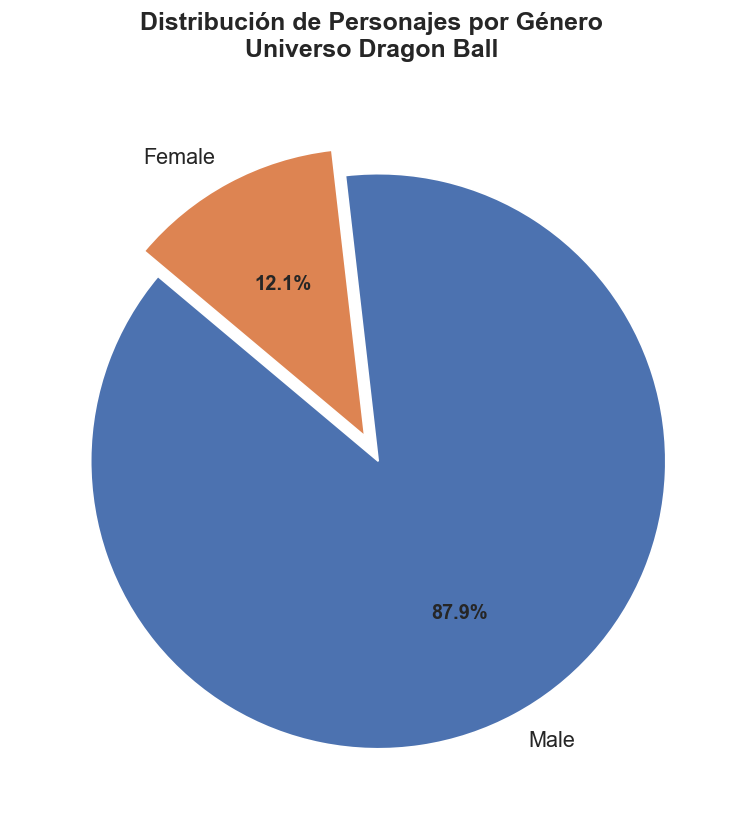

 Gráfico 1 guardado.


In [14]:
genero_counts = df["gender"].value_counts()
colores = ["#4C72B0", "#DD8452"]
explotar = [0.05, 0.05]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    genero_counts,
    labels=genero_counts.index,
    autopct="%1.1f%%",
    colors=colores,
    explode=explotar,
    startangle=140,
    textprops={"fontsize": 13}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")

ax.set_title("Distribución de Personajes por Género\nUniverso Dragon Ball",
             fontsize=15, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("grafico_torta_genero.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Gráfico 1 guardado.")

### Gráfico 2 — Personajes por Raza (Barras)

Este gráfico muestra la cantidad de personajes por raza, permitiendo identificar cuáles son las razas más representadas en la serie. Los Saiyans lideran, seguidos de Androids y Humanos.

/var/folders/s1/9k89mxwj5ls1xchp_c4qcc6r0000gn/T/ipykernel_50176/3866110464.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(raza_counts.index, rotation=40, ha="right", fontsize=10)


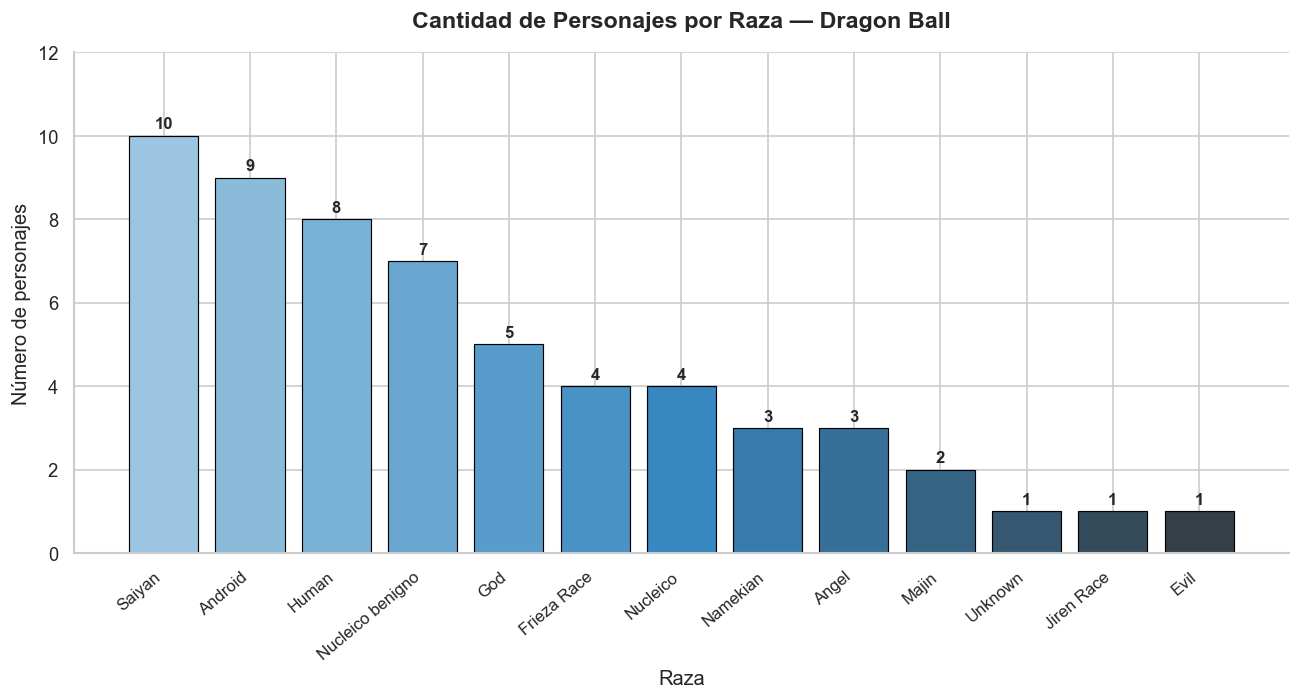

 Gráfico 2 guardado.


In [15]:
raza_counts = df["race"].value_counts()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(raza_counts.index, raza_counts.values,
              color=sns.color_palette("Blues_d", len(raza_counts)),
              edgecolor="black", linewidth=0.7)

# Etiquetas encima de cada barra
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            str(int(bar.get_height())),
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Cantidad de Personajes por Raza — Dragon Ball",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Raza", fontsize=12)
ax.set_ylabel("Número de personajes", fontsize=12)
ax.set_xticklabels(raza_counts.index, rotation=40, ha="right", fontsize=10)
ax.set_ylim(0, raza_counts.max() + 2)
sns.despine()
plt.tight_layout()
plt.savefig("grafico_barras_razas.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Gráfico 2 guardado.")

### Gráfico 3 — Héroes vs Villanos vs Neutros (Barras Horizontales)

Clasifica los personajes en tres categorías según su bando en la serie. Permite ver la distribución de alianzas en el universo Dragon Ball.

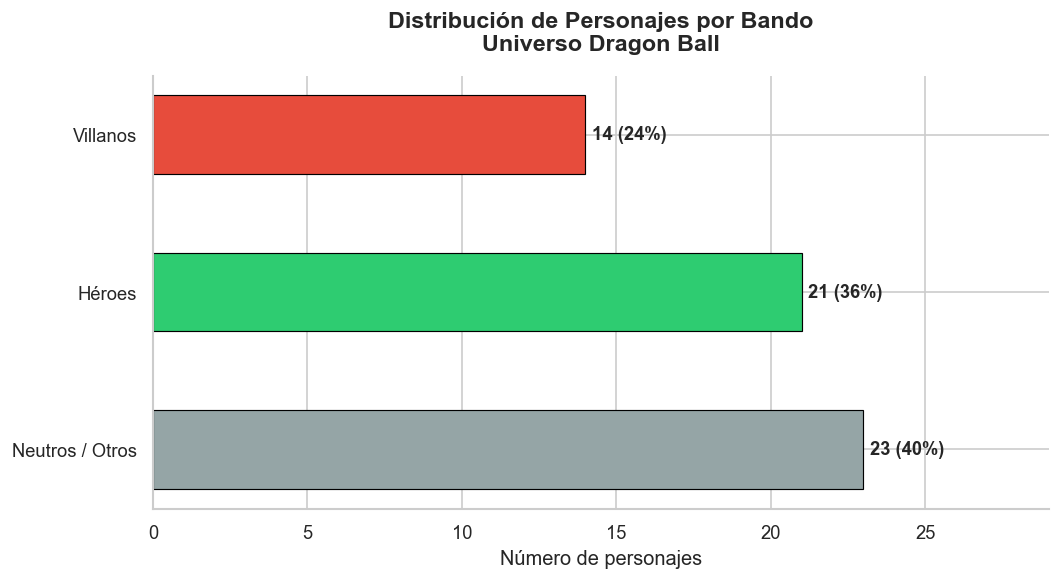

 Gráfico 3 guardado.


In [16]:
# Clasificar personajes por bando
def clasificar(afil):
    if afil in ["Z Fighter", "Assistant of Beerus", "Assistant of Vermoud"]:
        return "Héroes"
    elif afil in ["Army of Frieza", "Villain"]:
        return "Villanos"
    else:
        return "Neutros / Otros"

df["bando"] = df["affiliation"].apply(clasificar)
bando_counts = df["bando"].value_counts()

colores_bando = {"Héroes": "#2ecc71", "Villanos": "#e74c3c", "Neutros / Otros": "#95a5a6"}
colores_lista = [colores_bando[b] for b in bando_counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(bando_counts.index, bando_counts.values,
               color=colores_lista, edgecolor="black", linewidth=0.7, height=0.5)

for bar in bars:
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())} ({int(bar.get_width())/len(df)*100:.0f}%)",
            va="center", fontsize=11, fontweight="bold")

ax.set_title("Distribución de Personajes por Bando\nUniverso Dragon Ball",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Número de personajes", fontsize=12)
ax.set_xlim(0, bando_counts.max() + 6)
sns.despine()
plt.tight_layout()
plt.savefig("grafico_bandos.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Gráfico 3 guardado.")

---
## 6. Conclusiones

El análisis exploratorio de los **58 personajes** del universo Dragon Ball revela los siguientes hallazgos principales:

1. **Los Saiyans son la raza dominante** con 10 personajes, seguidos de Androids (9) y Humanos (8). Esto refleja el papel central de la raza Saiyan en la narrativa de la serie, donde los protagonistas principales pertenecen a ella.

2. **Brecha de género significativa**: el 87.9% de los personajes son masculinos (51) frente a solo 7 femeninos (12.1%). Por cada personaje femenino hay aproximadamente 7.3 masculinos, lo que evidencia una subrepresentación histórica de la mujer en Dragon Ball.

3. **Los Z Fighters son el grupo más numeroso** con 19 miembros, representando el 32.8% del total. Esto tiene sentido dado que la serie gira en torno a este equipo de héroes.

4. **Diversidad de bandos equilibrada**: los héroes (36.2%) y villanos (24.1%) coexisten con un grupo neutro/otros (39.7%) que incluye personajes de afiliación ambigua como freelancers y luchadores independientes.

5. **13 razas únicas** conforman el universo Dragon Ball, desde Saiyans y Namekianos hasta razas más exóticas como Nucleico benigno y Jiren Race, lo que demuestra la riqueza y diversidad del universo creado por Akira Toriyama.